In [1]:
import DestinyResearch as dr
import polars as pl

In [2]:
raw_orders = "/media/julien/HDD/data/raw/provider=HKEX/venue=HKEX/product=HSI/year=2026/month=02/hkex-hsi_20260216_orders.parquet"
raw_trades = "/media/julien/HDD/data/raw/provider=HKEX/venue=HKEX/product=HSI/year=2026/month=02/hkex-hsi_20260216_trades.parquet"

# Reading Trades file

In [4]:
pl.read_parquet_schema(raw_trades)

Schema([('send_time_ns', Int64),
        ('seq_num', Int64),
        ('msg_index', Int32),
        ('trade_time_ns', Int64),
        ('orderbook_id', Int64),
        ('symbol', String),
        ('class_code', String),
        ('order_id', Int64),
        ('price', Int32),
        ('quantity', Int64),
        ('trade_id', Int64),
        ('side', Int8),
        ('deal_type', Int8),
        ('combo_group_id', Int32),
        ('trade_condition', Int16),
        ('deal_info', Int16)])

In [5]:
df_trades = pl.read_parquet(raw_trades).filter(pl.col("symbol") == "HSIG6")

In [6]:
df_trades.shape

(34123, 16)

In [67]:
df_trades.head()
#df_trades.slice(5000, 5)

send_time_ns,seq_num,msg_index,trade_time_ns,orderbook_id,symbol,class_code,order_id,price,quantity,trade_id,side,deal_type,combo_group_id,trade_condition,deal_info
i64,i64,i32,i64,i64,str,str,i64,i32,i64,i64,i8,i8,i32,i16,i16
1771204440020000000,253965,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253125,26519,1,8114217430110175406,2,2,0,0,0
1771204440020000000,253966,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253124,26519,39,8114217430110175406,3,3,0,0,0
1771204440020000000,253967,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253126,26519,3,8114217430110175406,2,2,0,0,0
1771204440020000000,253968,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253346,26519,2,8114217430110175406,2,2,0,0,0
1771204440020000000,253969,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253436,26519,1,8114217430110175406,2,2,0,0,0


## Columns

**Deal Info:** Information Bitmap of a deal.
- 1: Reported Trade
- 0: None

In [11]:
df_trades.get_column("deal_info").value_counts()

deal_info,count
i16,u32
0,34120
1,3


**Trade condition:** The condition in which a trade was executed. Field is a Bitmap.
- 0:  None
- 1:  Late Trade
- 2:  Internal Trade/Crossing
- 8:  Buy Write
- 16: Off Market

In [10]:
df_trades.get_column("trade_condition").value_counts()

trade_condition,count
i16,u32
0,34123


**Combo group ID:** Used to group combo and leg executions together

In [12]:
df_trades.get_column("combo_group_id").value_counts()

combo_group_id,count
i32,u32
235,1
793,1
759,1
973,1
730,1
…,…
532,1
234,1
224,1


**Deal type:** Deal Type Bitmap
- 0: None
- 1: Printable
- 2: Occurred at Cross
- 3: Reported Trade

In [13]:
df_trades.get_column("deal_type").value_counts()

deal_type,count
i8,u32
3,12
2,27
4,3
1,34081


**Side:** Side of Orderbook ID
- 0: Not available
- 1: Not Defined
- 2: Buy Order
- 3: Sell Order

In [14]:
df_trades.get_column("side").value_counts()

side,count
i8,u32
3,17480
0,96
2,16547


In [15]:
df_trades.get_column("orderbook_id").value_counts()

orderbook_id,count
i64,u32
135335842,34123


# Reading Orders file

In [17]:
pl.read_parquet_schema(raw_orders)

Schema([('send_time_ns', Int64),
        ('seq_num', Int64),
        ('msg_index', Int32),
        ('msg_type', Int32),
        ('orderbook_id', Int64),
        ('symbol', String),
        ('class_code', String),
        ('order_id', Int64),
        ('price', Int32),
        ('quantity', Int32),
        ('side', Int8),
        ('lot_type', Int8),
        ('order_type', Int16),
        ('orderbook_position', Int32)])

In [18]:
df_orders = pl.read_parquet(raw_orders).filter(pl.col("symbol") == "HSIG6")

In [29]:
df_orders.shape

(1429653, 14)

In [20]:
df_orders.head()

send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
i64,i64,i32,i32,i64,str,str,i64,i32,i32,i8,i8,i16,i32
1771189627321000000,200,0,330,135335842,"""HSIG6""","""HSI""",8113133586548788967,26521,1,0,2,0,1
1771189627321000000,201,0,330,135335842,"""HSIG6""","""HSI""",8113133586548708223,26508,3,0,2,0,2
1771189627321000000,202,0,330,135335842,"""HSIG6""","""HSI""",8113133586548790586,26501,2,0,2,0,3
1771189627321000000,203,0,330,135335842,"""HSIG6""","""HSI""",8113133586548773899,26455,2,0,2,0,4
1771189627321000000,204,0,330,135335842,"""HSIG6""","""HSI""",8113133586548708225,26428,3,0,2,0,5


In [57]:
df_orders.filter(pl.col("msg_type") == 335)

send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
i64,i64,i32,i32,i64,str,str,i64,i32,i32,i8,i8,i16,i32
1771202700070000000,55604,0,335,135335842,"""HSIG6""","""HSI""",0,0,0,-1,0,0,0
1771204440020000000,254004,0,335,135335842,"""HSIG6""","""HSI""",0,0,0,-1,0,0,0


In [5]:
from datetime import datetime

ns = 1771189627321000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"First order message:  {date}")

ns = 1771202700070000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"First clear message:  {date}")

ns = 1771204440010000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"First trade message:  {date}")

ns = 1771204440020000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"Second clear message: {date}")

First order message:  2026-02-15 22:07:07.321000
First clear message:  2026-02-16 01:45:00.070000
First trade message:  2026-02-16 02:14:00.010000
Second clear message: 2026-02-16 02:14:00.020000


In [23]:
df_orders.get_column("msg_index").value_counts()

msg_index,count
i32,u32
0,1429653


In [28]:
df_trades.get_column("seq_num").describe()

statistic,value
str,f64
"""count""",34123.0
"""null_count""",0.0
"""mean""",2.1047e7
"""std""",1.3432e7
"""min""",6.0
"""25%""",8.809547e6
"""50%""",2.0144384e7
"""75%""",3.3114718e7
"""max""",4.3804991e7


In [47]:
df_trades.head(100)

send_time_ns,seq_num,msg_index,trade_time_ns,orderbook_id,symbol,class_code,order_id,price,quantity,trade_id,side,deal_type,combo_group_id,trade_condition,deal_info
i64,i64,i32,i64,i64,str,str,i64,i32,i64,i64,i8,i8,i32,i16,i16
1771204440020000000,253965,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253125,26519,1,8114217430110175406,2,2,0,0,0
1771204440020000000,253966,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253124,26519,39,8114217430110175406,3,3,0,0,0
1771204440020000000,253967,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253126,26519,3,8114217430110175406,2,2,0,0,0
1771204440020000000,253968,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253346,26519,2,8114217430110175406,2,2,0,0,0
1771204440020000000,253969,0,1771204440010000000,135335842,"""HSIG6""","""HSI""",8114217430110253436,26519,1,8114217430110175406,2,2,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1771204501868000000,272292,0,1771204501860000000,135335842,"""HSIG6""","""HSI""",8114217430110265805,26519,1,8114217430110175521,3,1,0,0,0
1771204501868000000,272293,0,1771204501860000000,135335842,"""HSIG6""","""HSI""",8114217430110265806,26519,1,8114217430110175521,3,1,0,0,0
1771204501868000000,272294,0,1771204501860000000,135335842,"""HSIG6""","""HSI""",8114217430110266302,26519,1,8114217430110175521,3,1,0,0,0


In [53]:
df_orders.filter(pl.col("seq_num") > 272300)

send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
i64,i64,i32,i32,i64,str,str,i64,i32,i32,i8,i8,i16,i32
1771204501868000000,272301,0,332,135335842,"""HSIG6""","""HSI""",8114217430110265473,0,0,1,0,0,0
1771204501868000000,272302,0,330,135335842,"""HSIG6""","""HSI""",8114217430110266377,26529,2,1,2,0,5
1771204501868000000,272304,0,330,135335842,"""HSIG6""","""HSI""",8114217430110266378,26517,1,0,2,0,2
1771204501868000000,272315,0,330,135335842,"""HSIG6""","""HSI""",8114217430110266383,26523,1,1,2,0,3
1771204501868000000,272317,0,332,135335842,"""HSIG6""","""HSI""",8114217430110266377,0,0,1,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1771269029051000000,45999072,0,332,135335842,"""HSIG6""","""HSI""",8114217430121554097,0,0,1,0,0,0
1771269029051000000,45999073,0,332,135335842,"""HSIG6""","""HSI""",8114217430121573099,0,0,0,0,0,0
1771269029057000000,45999076,0,332,135335842,"""HSIG6""","""HSI""",8114217430121573091,0,0,1,0,0,0


In [1]:
import DestinyResearch as dr

In [2]:
tbl = dr.get_mbo("HSIG26", "2026-02-02")

In [3]:
df = tbl.to_pandas()

In [4]:
df.value_counts("action")

action
CANCEL    4398555
ADD       4393936
TRADE      129172
CLEAR           4
Name: count, dtype: int64

In [7]:
df[df["order_id"] == 8108676166384180804]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
993,1769994900511000000,1769994900511000000,HKEX,HSI,HSIG26,ADD,BID,27234000000000,2,8108676166384180804,132,1142393,0,135335842
1046,1769994900673000000,1769994900673000000,HKEX,HSI,HSIG26,CANCEL,BID,0,2,8108676166384180804,132,1143652,0,135335842


In [5]:
df[df["action"] == "CLEAR"]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
220,1769993100062000000,1769993100062000000,HKEX,HSI,HSIG26,CLEAR,NONE,0,0,0,132,65851,0,135335842
455,1769994840025000000,1769994840025000000,HKEX,HSI,HSIG26,CLEAR,NONE,0,0,0,132,1101821,0,135335842
3724115,1770006600062000000,1770006600062000000,HKEX,HSI,HSIG26,CLEAR,NONE,0,0,0,132,66918181,0,135335842
3724222,1770008340018000000,1770008340018000000,HKEX,HSI,HSIG26,CLEAR,NONE,0,0,0,132,67163392,0,135335842


In [20]:
df.iloc[1090:1100]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
1090,1769994900740000000,1769994900743000000,HKEX,HSI,HSIG26,TRADE,ASK,27247000000000,1,8108676166384169726,132,1144039,0,135335842
1091,1769994900740000000,1769994900743000000,HKEX,HSI,HSIG26,CANCEL,ASK,27247000000000,1,8108676166384169726,132,1144039,0,135335842
1092,1769994900743000000,1769994900743000000,HKEX,HSI,HSIG26,ADD,ASK,27247000000000,2,8108676166384181239,132,1144043,0,135335842
1093,1769994900806000000,1769994900806000000,HKEX,HSI,HSIG26,CANCEL,ASK,0,1,8108676166384180905,132,1144340,0,135335842
1094,1769994900806000000,1769994900806000000,HKEX,HSI,HSIG26,ADD,ASK,27266000000000,1,8108676166384180905,132,1144341,0,135335842
1095,1769994900806000000,1769994900806000000,HKEX,HSI,HSIG26,ADD,ASK,27249000000000,2,8108676166384181284,132,1144342,0,135335842
1096,1769994900825000000,1769994900825000000,HKEX,HSI,HSIG26,ADD,ASK,27217000000000,1,8108676166384181290,132,1144363,0,135335842
1097,1769994900825000000,1769994900825000000,HKEX,HSI,HSIG26,CANCEL,ASK,0,2,8108676166384180820,132,1144371,0,135335842
1098,1769994900825000000,1769994900825000000,HKEX,HSI,HSIG26,CANCEL,BID,0,1,8108676166384180575,132,1144372,0,135335842
1099,1769994900825000000,1769994900825000000,HKEX,HSI,HSIG26,ADD,ASK,27251000000000,2,8108676166384181296,132,1144376,0,135335842


In [21]:
df[df["order_id"] == 8108676166384181290]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
1096,1769994900825000000,1769994900825000000,HKEX,HSI,HSIG26,ADD,ASK,27217000000000,1,8108676166384181290,132,1144363,0,135335842
1104,1769994900860000000,1769994900863000000,HKEX,HSI,HSIG26,TRADE,ASK,27217000000000,1,8108676166384181290,132,1144698,0,135335842
1105,1769994900860000000,1769994900863000000,HKEX,HSI,HSIG26,CANCEL,ASK,27217000000000,1,8108676166384181290,132,1144698,0,135335842


In [22]:
tbl_2 = dr.get_mbp1("HSIG26", "2026-02-02")

In [23]:
df_mbp1 = tbl_2.to_pandas()

In [24]:
n = 1040

In [25]:
df_mbp1.iloc[n:n+25]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
1040,1769994900670000000,1769994900673000000,CANCEL,BID,27235.0,132,1143641,27235.0,27247.0,2.0,9.0,2.0,6.0
1041,1769994900670000000,1769994900673000000,TRADE,BID,27235.0,132,1143644,27235.0,27247.0,2.0,9.0,2.0,6.0
1042,1769994900670000000,1769994900673000000,CANCEL,BID,27235.0,132,1143644,27235.0,27247.0,1.0,9.0,1.0,6.0
1043,1769994900670000000,1769994900673000000,TRADE,BID,27235.0,132,1143645,27235.0,27247.0,1.0,9.0,1.0,6.0
1044,1769994900670000000,1769994900673000000,CANCEL,BID,27235.0,132,1143645,27234.0,27247.0,2.0,9.0,1.0,6.0
1045,1769994900673000000,1769994900673000000,ADD,ASK,27255.0,132,1143651,27234.0,27247.0,2.0,9.0,1.0,6.0
1046,1769994900673000000,1769994900673000000,CANCEL,BID,0.0,132,1143652,27234.0,27247.0,2.0,9.0,1.0,6.0
1047,1769994900673000000,1769994900673000000,ADD,BID,27226.0,132,1143657,27234.0,27247.0,2.0,9.0,1.0,6.0
1048,1769994900673000000,1769994900673000000,ADD,BID,27225.0,132,1143659,27234.0,27247.0,2.0,9.0,1.0,6.0
1049,1769994900674000000,1769994900674000000,ADD,BID,27199.0,132,1143666,27234.0,27247.0,2.0,9.0,1.0,6.0


In [26]:
temp = df_mbp1[(df_mbp1["ts_event"] <= 1769994900825000000) & (df_mbp1["ts_event"] >= 1769994840025000000)]

In [27]:
temp

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
455,1769994840025000000,1769994840025000000,CLEAR,NONE,0.0,132,1101821,NaN,NaN,NaN,NaN,NaN,NaN
456,1769994840025000000,1769994840025000000,ADD,ASK,27226.0,132,1101822,NaN,27226.0,NaN,1.0,NaN,1.0
457,1769994840025000000,1769994840025000000,ADD,ASK,27247.0,132,1101823,NaN,27226.0,NaN,1.0,NaN,1.0
458,1769994840025000000,1769994840025000000,ADD,ASK,27249.0,132,1101824,NaN,27226.0,NaN,1.0,NaN,1.0
459,1769994840025000000,1769994840025000000,ADD,ASK,27254.0,132,1101825,NaN,27226.0,NaN,1.0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1769994900806000000,1769994900806000000,ADD,ASK,27249.0,132,1144342,27234.0,27247.0,2.0,14.0,1.0,10.0
1096,1769994900825000000,1769994900825000000,ADD,ASK,27217.0,132,1144363,27234.0,27217.0,2.0,1.0,1.0,1.0
1097,1769994900825000000,1769994900825000000,CANCEL,ASK,0.0,132,1144371,27234.0,27217.0,2.0,1.0,1.0,1.0
1098,1769994900825000000,1769994900825000000,CANCEL,BID,0.0,132,1144372,27234.0,27217.0,2.0,1.0,1.0,1.0


In [28]:
temp[temp["action"] == "TRADE"]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
938,1769994900100000000,1769994900107000000,TRADE,ASK,27226.0,132,1141777,27208.0,27226.0,3.0,3.0,3.0,3.0
940,1769994900100000000,1769994900107000000,TRADE,ASK,27226.0,132,1141778,27208.0,27226.0,3.0,2.0,3.0,2.0
942,1769994900100000000,1769994900107000000,TRADE,ASK,27226.0,132,1141779,27208.0,27226.0,3.0,1.0,3.0,1.0
965,1769994900220000000,1769994900225000000,TRADE,ASK,27247.0,132,1142008,27208.0,27247.0,4.0,7.0,4.0,3.0
1027,1769994900660000000,1769994900668000000,TRADE,BID,27244.0,132,1143418,27244.0,27247.0,5.0,9.0,5.0,6.0
1031,1769994900670000000,1769994900673000000,TRADE,BID,27244.0,132,1143637,27244.0,27247.0,4.0,9.0,4.0,6.0
1033,1769994900670000000,1769994900673000000,TRADE,BID,27244.0,132,1143638,27244.0,27247.0,3.0,9.0,3.0,6.0
1035,1769994900670000000,1769994900673000000,TRADE,BID,27244.0,132,1143639,27244.0,27247.0,2.0,9.0,2.0,6.0
1037,1769994900670000000,1769994900673000000,TRADE,BID,27244.0,132,1143640,27244.0,27247.0,1.0,9.0,1.0,6.0
1039,1769994900670000000,1769994900673000000,TRADE,BID,27235.0,132,1143641,27235.0,27247.0,3.0,9.0,2.0,6.0


In [29]:
temp[(temp["side"] == "BID") & (temp["price"] == 27234.0)]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
993,1769994900511000000,1769994900511000000,ADD,BID,27234.0,132,1142393,27244.0,27247.0,2.0,8.0,2.0,5.0


In [16]:
df_mbp1[df_mbp1["action"] == "CLEAR"]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
220,1769993100062000000,1769993100062000000,CLEAR,NONE,0.0,132,65851,NaN,NaN,NaN,NaN,NaN,NaN
455,1769994840025000000,1769994840025000000,CLEAR,NONE,0.0,132,1101821,NaN,NaN,NaN,NaN,NaN,NaN
3724115,1770006600062000000,1770006600062000000,CLEAR,NONE,0.0,132,66918181,NaN,NaN,NaN,NaN,NaN,NaN
3724222,1770008340018000000,1770008340018000000,CLEAR,NONE,0.0,132,67163392,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
from datetime import datetime

ns = 1769993100062000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"First order message:  {date}")

ns = 1769994840025000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"First clear message:  {date}")

ns = 1770006600062000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"First trade message:  {date}")

ns = 1770008340018000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"Second clear message: {date}")

First order message:  2026-02-02 01:45:00.062000
First clear message:  2026-02-02 02:14:00.025000
First trade message:  2026-02-02 05:30:00.062000
Second clear message: 2026-02-02 05:59:00.018000


In [1]:
import pandas as pd
import polars as pl

In [7]:
df_raw = pd.read_parquet("/media/julien/HDD/data/raw/provider=HKEX/venue=HKEX/product=HSI/year=2026/month=02/hkex-hsi_20260202_orders.parquet")

In [4]:
df_trades = pd.read_parquet("/media/julien/HDD/data/raw/provider=HKEX/venue=HKEX/product=HSI/year=2026/month=02/hkex-hsi_20260202_trades.parquet")

In [8]:
df_trades = df_trades[df_trades["symbol"] == "HSIG6"]

NameError: name 'df_trades' is not defined

In [9]:
df_raw = df_raw[df_raw["symbol"] == "HSIG6"]

In [7]:
df_raw = df_raw[df_raw["seq_num"] <= 1144363]

In [8]:
df_raw[df_raw["send_time_ns"] == 1769994900511000000]

,send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
1523,1769994900511000000,1142393,0,330,135335842,HSIG6,HSI,8108676166384180804,27234,2,0,2,0,3
1524,1769994900511000000,1142394,0,330,135335842,HSIG6,HSI,8108676166384180805,27255,2,1,2,0,5


In [9]:
df_raw[df_raw["order_id"] == 8108676166384180804]

,send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
1523,1769994900511000000,1142393,0,330,135335842,HSIG6,HSI,8108676166384180804,27234,2,0,2,0,3
1726,1769994900673000000,1143652,0,332,135335842,HSIG6,HSI,8108676166384180804,0,0,0,0,0,0


In [10]:
from datetime import datetime

ns = 1769994900511000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"Ajout:  {date}")

ns = 1769994900673000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"Retrait:  {date}")

ns = 1769994900680000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"Apparition dans le book:  {date}")

Ajout:  2026-02-02 02:15:00.511000
Retrait:  2026-02-02 02:15:00.673000
Apparition dans le book:  2026-02-02 02:15:00.680000


In [11]:
df_raw

,send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
40,1769980027401000000,91,0,330,135335842,HSIG6,HSI,8107592322797088415,27250,1,0,2,0,1
41,1769980027401000000,92,0,330,135335842,HSIG6,HSI,8107592322826584382,27079,1,0,2,0,2
42,1769980027401000000,93,0,330,135335842,HSIG6,HSI,8107592322822229351,27058,2,0,2,0,3
43,1769980027401000000,94,0,330,135335842,HSIG6,HSI,8107592322822388870,27028,1,0,2,0,4
44,1769980027401000000,95,0,330,135335842,HSIG6,HSI,8106405125130578747,27016,1,0,2,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1809,1769994900743000000,1144043,0,330,135335842,HSIG6,HSI,8108676166384181239,27247,2,1,2,0,6
1847,1769994900806000000,1144340,0,332,135335842,HSIG6,HSI,8108676166384180905,0,0,1,0,0,0
1848,1769994900806000000,1144341,0,330,135335842,HSIG6,HSI,8108676166384180905,27266,1,1,2,0,13
1849,1769994900806000000,1144342,0,330,135335842,HSIG6,HSI,8108676166384181284,27249,2,1,2,0,8


In [66]:
df_raw[df_raw["msg_type"] == 330].groupby("side")["price"].agg(["min", "max"])

,min,max
side,,
0,24405,27250
1,27217,30000


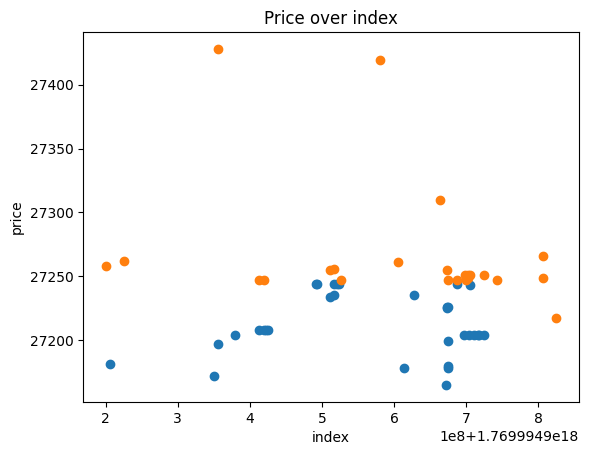

In [86]:
import matplotlib.pyplot as plt

y_1 = df_raw[(df_raw["msg_type"] == 330) & (df_raw["side"] == 0) & (df_raw.index > 1450)]["price"]
x_1 = df_raw[(df_raw["msg_type"] == 330) & (df_raw["side"] == 0) & (df_raw.index > 1450)]["send_time_ns"]

y_2 = df_raw[(df_raw["msg_type"] == 330) & (df_raw["side"] == 1) & (df_raw.index > 1450)]["price"]
x_2 = df_raw[(df_raw["msg_type"] == 330) & (df_raw["side"] == 1) & (df_raw.index > 1450)]["send_time_ns"]

plt.scatter(x_1, y_1)
plt.scatter(x_2, y_2)
plt.xlabel("index")
plt.ylabel("price")
plt.title("Price over index")
plt.show()


In [12]:
df_raw[df_raw["order_id"] == 8108676166384181290]

,send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
1851,1769994900825000000,1144363,0,330,135335842,HSIG6,HSI,8108676166384181290,27217,1,1,2,0,1


In [13]:
df_trades[df_trades["order_id"] == 8108676166384181290]

,send_time_ns,seq_num,msg_index,trade_time_ns,orderbook_id,symbol,class_code,order_id,price,quantity,trade_id,side,deal_type,combo_group_id,trade_condition,deal_info
140,1769994900863000000,1144698,0,1769994900860000000,135335842,HSIG6,HSI,8108676166384181290,27217,1,8108676166384091491,3,1,0,0,0


In [14]:
df_trades[(df_trades["combo_group_id"] != 0)]

,send_time_ns,seq_num,msg_index,trade_time_ns,orderbook_id,symbol,class_code,order_id,price,quantity,trade_id,side,deal_type,combo_group_id,trade_condition,deal_info
174,1769994901409000000,1147483,0,1769994901400000000,135335842,HSIG6,HSI,8108676166384182270,27233,1,8108676166384091551,2,1,2,0,0
184,1769994901655000000,1148579,0,1769994901650000000,135335842,HSIG6,HSI,0,27216,1,8108676166384091569,0,1,4,0,0
208,1769994902281000000,1152113,0,1769994902280000000,135335842,HSIG6,HSI,0,27204,1,8108676166384091610,0,1,6,0,0
911,1769994951988000000,1382328,0,1769994951980000000,135335842,HSIG6,HSI,8108676166384257302,27171,1,8108676166384093250,2,1,15,0,0
914,1769994951988000000,1382332,0,1769994951980000000,135335842,HSIG6,HSI,8108676166384269648,27171,1,8108676166384093250,2,1,16,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154095,1770056773095000000,151321925,0,1770056773090000000,135335842,HSIG6,HSI,0,26963,1,8108676166384457258,0,1,2441,0,0
154105,1770056773330000000,151323336,0,1770056773330000000,135335842,HSIG6,HSI,8108676166417501471,26961,1,8108676166384457269,2,1,2442,0,0
154109,1770056773330000000,151323356,0,1770056773330000000,135335842,HSIG6,HSI,0,26961,2,8108676166384457273,0,1,2443,0,0
155228,1770015480407000000,134,0,1770015480400000000,135335842,HSIG6,HSI,0,26725,46,8108676166384347506,0,4,1650,2,1


In [54]:
df_mbp1.head()

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
0,1769980027401000000,1769980027401000000,ADD,BID,27250.0,132,91,27250.0,NaN,1.0,NaN,1.0,NaN
1,1769980027401000000,1769980027401000000,ADD,BID,27079.0,132,92,27250.0,NaN,1.0,NaN,1.0,NaN
2,1769980027401000000,1769980027401000000,ADD,BID,27058.0,132,93,27250.0,NaN,1.0,NaN,1.0,NaN
3,1769980027401000000,1769980027401000000,ADD,BID,27028.0,132,94,27250.0,NaN,1.0,NaN,1.0,NaN
4,1769980027401000000,1769980027401000000,ADD,BID,27016.0,132,95,27250.0,NaN,1.0,NaN,1.0,NaN


In [53]:
df_mbp1 = pd.read_parquet("/media/julien/HDD/data/reconstructed/provider=HKEX/venue=HKEX/product=HSI/contract=HSIG26/year=2026/month=02/HSIG26_20260202_mbp1.parquet")

In [58]:
df_mbp1.iloc[125090: 125095]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
125090,1769995460290000000,1769995460290000000,ADD,ASK,27080.0,132,4026165,27079.0,27080.0,2.0,8.0,1.0,7.0
125091,1769995460290000000,1769995460290000000,ADD,BID,27076.0,132,4026168,27079.0,27080.0,2.0,8.0,1.0,7.0
125092,1769995460290000000,1769995460290000000,ADD,ASK,27079.0,132,4026173,27079.0,27079.0,2.0,1.0,1.0,1.0
125093,1769995460290000000,1769995460290000000,CANCEL,ASK,27080.0,132,4026181,27079.0,27079.0,2.0,1.0,1.0,1.0
125094,1769995460290000000,1769995460290000000,CANCEL,ASK,27079.0,132,4026182,27079.0,27080.0,2.0,7.0,1.0,6.0


In [67]:
con.execute("""
    SELECT ts_event, sequence, action, side, 
           price / 1e9 as price, size, order_id
    FROM read_parquet('/media/julien/HDD/data/normalized/provider=HKEX/venue=HKEX/product=HSI/contract=HSIG26/year=2026/month=02/HSIG26_20260202_mbo.parquet')
    WHERE ts_event <= 1769995460290000000 + 5000000
      AND ts_event >= 1769995460290000000 - 75000000
    ORDER BY ts_event, sequence
""").df()

,ts_event,sequence,action,side,price,size,order_id
0,1769995460218000000,4025744,CANCEL,ASK,27082.0,1,8108676166385053261
1,1769995460218000000,4025765,CANCEL,ASK,27082.0,1,8108676166385224595
2,1769995460218000000,4025766,ADD,ASK,27081.0,1,8108676166385224650
3,1769995460218000000,4025768,CANCEL,BID,27069.0,2,8108676166385222647
4,1769995460234000000,4025852,CANCEL,ASK,27081.0,1,8108676166385224650
5,1769995460235000000,4025857,ADD,ASK,27082.0,1,8108676166385224677
6,1769995460278000000,4025991,CANCEL,BID,27078.0,1,8108676166385224466
7,1769995460278000000,4026010,CANCEL,BID,27077.0,1,8108676166385224480
8,1769995460278000000,4026015,ADD,ASK,27080.0,1,8108676166385224734
9,1769995460278000000,4026018,CANCEL,ASK,27082.0,1,8108676166385224677


In [71]:
df_mbp1[(df_mbp1["ts_event"] > 1769994840025000000) & (df_mbp1["ts_event"] <= 1769995460290000000) & (df_mbp1["price"] == 27079)]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
3281,1769994911436000000,1769994911436000000,ADD,BID,27079.0,132,1206101,27135.0,27148.0,1.0,4.0,1.0,4.0
3303,1769994911441000000,1769994911441000000,CANCEL,BID,27079.0,132,1206335,27126.0,27147.0,1.0,2.0,1.0,2.0
14463,1769994970152000000,1769994970152000000,ADD,BID,27079.0,132,1477642,27127.0,27129.0,2.0,1.0,2.0,1.0
14554,1769994970352000000,1769994970352000000,CANCEL,BID,27079.0,132,1479450,27123.0,27126.0,5.0,1.0,5.0,1.0
17407,1769994981343000000,1769994981343000000,ADD,BID,27079.0,132,1525151,27135.0,27138.0,2.0,3.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125031,1769995460200000000,1769995460205000000,TRADE,ASK,27079.0,132,4025042,27078.0,27079.0,2.0,1.0,2.0,1.0
125032,1769995460200000000,1769995460205000000,CANCEL,ASK,27079.0,132,4025042,27078.0,27080.0,2.0,7.0,2.0,6.0
125042,1769995460205000000,1769995460205000000,ADD,BID,27079.0,132,4025132,27079.0,27080.0,2.0,7.0,1.0,6.0
125092,1769995460290000000,1769995460290000000,ADD,ASK,27079.0,132,4026173,27079.0,27079.0,2.0,1.0,1.0,1.0


In [88]:
df_mbp1.iloc[125035:125095]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
125035,1769995460205000000,1769995460205000000,CANCEL,ASK,27081.0,132,4025067,27078.0,27080.0,3.0,7.0,3.0,6.0
125036,1769995460205000000,1769995460205000000,CANCEL,ASK,27100.0,132,4025068,27078.0,27080.0,3.0,7.0,3.0,6.0
125037,1769995460205000000,1769995460205000000,ADD,BID,27077.0,132,4025078,27078.0,27080.0,3.0,7.0,3.0,6.0
125038,1769995460205000000,1769995460205000000,CANCEL,BID,27076.0,132,4025079,27078.0,27080.0,3.0,7.0,3.0,6.0
125039,1769995460205000000,1769995460205000000,CANCEL,BID,27063.0,132,4025109,27078.0,27080.0,3.0,7.0,3.0,6.0
125040,1769995460205000000,1769995460205000000,CANCEL,BID,27085.0,132,4025125,27078.0,27080.0,3.0,7.0,3.0,6.0
125041,1769995460205000000,1769995460205000000,CANCEL,ASK,0.0,132,4025126,27078.0,27080.0,3.0,7.0,3.0,6.0
125042,1769995460205000000,1769995460205000000,ADD,BID,27079.0,132,4025132,27079.0,27080.0,2.0,7.0,1.0,6.0
125043,1769995460205000000,1769995460205000000,ADD,ASK,27087.0,132,4025133,27079.0,27080.0,2.0,7.0,1.0,6.0
125044,1769995460205000000,1769995460205000000,CANCEL,ASK,27082.0,132,4025151,27079.0,27080.0,2.0,7.0,1.0,6.0


In [11]:
df_raw[(df_raw["order_id"] == 8108676166385224516) | (df_raw["order_id"] == 8108676166385224789)]

,send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
962598,1769995460205000000,4025132,0,330,135335842,HSIG6,HSI,8108676166385224516,27079,2,0,2,0,1
962599,1769995460205000000,4025133,0,330,135335842,HSIG6,HSI,8108676166385224516,27087,3,1,2,0,43
962750,1769995460209000000,4025661,0,332,135335842,HSIG6,HSI,8108676166385224516,0,0,0,0,0,0
962751,1769995460209000000,4025662,0,332,135335842,HSIG6,HSI,8108676166385224516,0,0,1,0,0,0
962903,1769995460290000000,4026173,0,330,135335842,HSIG6,HSI,8108676166385224789,27079,1,1,2,0,1
962907,1769995460290000000,4026182,0,332,135335842,HSIG6,HSI,8108676166385224789,0,0,1,0,0,0


In [1]:
df_raw[df_raw["order_id"] == 8108676166385224789]

NameError: name 'df_raw' is not defined

In [86]:
df_mbp1[df_mbp1["ts_event"] == 1769995460290000000]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
125089,1769995460290000000,1769995460290000000,ADD,ASK,27080.0,132,4026150,27079.0,27080.0,2.0,7.0,1.0,6.0
125090,1769995460290000000,1769995460290000000,ADD,ASK,27080.0,132,4026165,27079.0,27080.0,2.0,8.0,1.0,7.0
125091,1769995460290000000,1769995460290000000,ADD,BID,27076.0,132,4026168,27079.0,27080.0,2.0,8.0,1.0,7.0
125092,1769995460290000000,1769995460290000000,ADD,ASK,27079.0,132,4026173,27079.0,27079.0,2.0,1.0,1.0,1.0
125093,1769995460290000000,1769995460290000000,CANCEL,ASK,27080.0,132,4026181,27079.0,27079.0,2.0,1.0,1.0,1.0
125094,1769995460290000000,1769995460290000000,CANCEL,ASK,27079.0,132,4026182,27079.0,27080.0,2.0,7.0,1.0,6.0


In [8]:
import DestinyResearch as dr
import pandas as pd
import polars as pl

In [3]:
tbl = dr.get_mbo("HSIG26", "2026-02-02")

In [4]:
tbl = tbl.to_pandas()

In [5]:
tbl.head()

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
0,1769980027401000000,1769980027401000000,HKEX,HSI,HSIG26,ADD,BID,27250000000000,1,8107592322797088415,132,91,0,135335842
1,1769980027401000000,1769980027401000000,HKEX,HSI,HSIG26,ADD,BID,27079000000000,1,8107592322826584382,132,92,0,135335842
2,1769980027401000000,1769980027401000000,HKEX,HSI,HSIG26,ADD,BID,27058000000000,2,8107592322822229351,132,93,0,135335842
3,1769980027401000000,1769980027401000000,HKEX,HSI,HSIG26,ADD,BID,27028000000000,1,8107592322822388870,132,94,0,135335842
4,1769980027401000000,1769980027401000000,HKEX,HSI,HSIG26,ADD,BID,27016000000000,1,8106405125130578747,132,95,0,135335842


In [6]:
tbl[tbl["order_id"] == 8108676166384169834]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
754,1769994840025000000,1769994840025000000,HKEX,HSI,HSIG26,ADD,BID,27167000000000,1,8108676166384169834,132,1102120,0,135335842
934,1769994900100000000,1769994900100000000,HKEX,HSI,HSIG26,CANCEL,BID,27167000000000,1,8108676166384169834,132,1141686,0,135335842


In [31]:
df = dr.get_mbo("HSIG26", "2026-02-10").to_pandas()

In [39]:
df[df["ts_event"] == 1770692062320000000]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
1366321,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,CANCEL,ASK,27254000000000,1,8111946388851413949,132,34543936,0,135335842
1366322,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,ADD,ASK,27253000000000,1,8111946388851414025,132,34543938,0,135335842
1366323,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,ADD,ASK,27251000000000,1,8111946388851414029,132,34543961,0,135335842
1366324,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,ADD,ASK,27251000000000,1,8111946388851414031,132,34543969,0,135335842
1366325,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,CANCEL,ASK,27253000000000,1,8111946388851412965,132,34544006,0,135335842
1366326,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,CANCEL,BID,27249000000000,2,8111946388851408214,132,34544018,0,135335842
1366327,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,CANCEL,BID,27249000000000,2,8111946388851408220,132,34544110,0,135335842
1366329,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,ADD,ASK,27250000000000,1,8111946388851414067,132,34544131,0,135335842
1366330,1770692062320000000,1770692062321000000,HKEX,HSI,HSIG26,TRADE,BID,27250000000000,1,8111946388851413723,132,34544120,0,135335842
1366331,1770692062320000000,1770692062321000000,HKEX,HSI,HSIG26,CANCEL,BID,27250000000000,1,8111946388851413723,132,34544120,0,135335842


In [37]:
df[(df["order_id"] == 8111946388851414067) | (df["order_id"] == 8111946388851413723)]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
1366250,1770692062039000000,1770692062039000000,HKEX,HSI,HSIG26,ADD,BID,27250000000000,1,8111946388851413723,132,34542585,0,135335842
1366329,1770692062320000000,1770692062320000000,HKEX,HSI,HSIG26,ADD,ASK,27250000000000,1,8111946388851414067,132,34544131,0,135335842
1366330,1770692062320000000,1770692062321000000,HKEX,HSI,HSIG26,TRADE,BID,27250000000000,1,8111946388851413723,132,34544120,0,135335842
1366331,1770692062320000000,1770692062321000000,HKEX,HSI,HSIG26,CANCEL,BID,27250000000000,1,8111946388851413723,132,34544120,0,135335842
1366344,1770692062322000000,1770692062322000000,HKEX,HSI,HSIG26,CANCEL,ASK,27250000000000,1,8111946388851414067,132,34544459,0,135335842


In [34]:
con.execute("""
    SELECT ts_event, bid_px_00 as bid, ask_px_00 as ask,
           (bid_px_00 - ask_px_00) as cross_amount
    FROM read_parquet('/media/julien/HDD/data/reconstructed/provider=HKEX/venue=HKEX/product=HSI/contract=HSIG26/year=2026/month=02/HSIG26_20260210_mbp1.parquet')
    WHERE bid_px_00 >= ask_px_00
      AND bid_px_00 IS NOT NULL AND ask_px_00 IS NOT NULL
    ORDER BY ts_event
""").df()

,ts_event,bid,ask,cross_amount
0,1770692062320000000,27250.0,27250.0,0.0
1,1770692062320000000,27250.0,27250.0,0.0


# Tests

In [1]:
import pandas as pd
import polars as pl

In [25]:
df_mbo = pd.read_parquet("/media/julien/HDD/data/normalized/provider=HKEX/venue=HKEX/product=HSI/contract=HSIM26/year=2026/month=02/HSIM26_20260210_mbo.parquet")

In [26]:
df_mbp1 = pd.read_parquet("/media/julien/HDD/data/reconstructed/provider=HKEX/venue=HKEX/product=HSI/contract=HSIM26/year=2026/month=02/HSIM26_20260210_mbp1.parquet")

In [16]:
df_mbp1[df_mbp1["sequence"] == 33559827]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
1188204,1771211689320000000,1771211689323000000,TRADE,ASK,26657.0,132,33559827,26656.0,26657.0,4.0,1.0,3.0,1.0
1188205,1771211689320000000,1771211689323000000,CANCEL,ASK,26657.0,132,33559827,26656.0,26658.0,4.0,2.0,3.0,2.0


In [22]:
import duckdb
import pandas as pd

con = duckdb.connect()
df = con.execute("""
    WITH numbered AS (
        SELECT *,
            ROW_NUMBER() OVER (
                ORDER BY ts_recv, sequence,
                CASE action WHEN 'TRADE' THEN 0 ELSE 1 END
            ) AS rn
        FROM read_parquet('/media/julien/HDD/data/reconstructed/provider=HKEX/venue=HKEX/product=HSI/contract=HSIM26/year=2026/month=02/HSIM26_20260210_mbp1.parquet')
    ),
    lagged AS (
        SELECT *,
            LAG(bid_px_00) OVER (ORDER BY rn) AS prev_bid,
            LAG(ask_px_00) OVER (ORDER BY rn) AS prev_ask
        FROM numbered
    )
    SELECT ts_recv, price as trade_price, 
           prev_bid as prev_bid, prev_ask as prev_ask,
           sequence
    FROM lagged
    WHERE action = 'TRADE'
      AND prev_bid IS NOT NULL AND prev_ask IS NOT NULL
      AND (price < prev_bid OR price > prev_ask)
""").df()
df['time_hkt'] = pd.to_datetime(df['ts_recv'], unit='ns', utc=True).dt.tz_convert('Asia/Hong_Kong')

In [23]:
df

,ts_recv,trade_price,prev_bid,prev_ask,sequence,time_hkt
0,1770689322961000000,27246.0,27268.0,27273.0,20563556,2026-02-10 10:08:42.961000+08:00
1,1770689322961000000,27246.0,27268.0,27273.0,20563557,2026-02-10 10:08:42.961000+08:00


In [28]:
df_mbp1[df_mbp1["ts_event"] == 1770689322950000000]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
641295,1770689322950000000,1770689322961000000,TRADE,BID,27246.0,132,20563556,27268.0,27273.0,6.0,2.0,1.0,1.0
641296,1770689322950000000,1770689322961000000,CANCEL,BID,27246.0,132,20563556,27268.0,27273.0,6.0,2.0,1.0,1.0
641297,1770689322950000000,1770689322961000000,TRADE,BID,27246.0,132,20563557,27268.0,27273.0,6.0,2.0,1.0,1.0
641298,1770689322950000000,1770689322961000000,CANCEL,BID,27246.0,132,20563557,27268.0,27273.0,6.0,2.0,1.0,1.0


In [93]:
df_mbp1.iloc[641260:641305]

,ts_event,ts_recv,action,side,price,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
641260,1770689322709000000,1770689322709000000,ADD,BID,27269.0,132,20562156,27269.0,27273.0,3.0,2.0,1.0,1.0
641261,1770689322709000000,1770689322709000000,CANCEL,BID,27269.0,132,20562159,27251.0,27273.0,2.0,2.0,1.0,1.0
641262,1770689322709000000,1770689322709000000,ADD,BID,27269.0,132,20562163,27269.0,27273.0,2.0,2.0,1.0,1.0
641263,1770689322709000000,1770689322709000000,CANCEL,BID,27269.0,132,20562181,27251.0,27273.0,2.0,2.0,1.0,1.0
641264,1770689322709000000,1770689322709000000,ADD,BID,27269.0,132,20562185,27269.0,27273.0,1.0,2.0,1.0,1.0
641265,1770689322709000000,1770689322709000000,CANCEL,BID,27251.0,132,20562195,27269.0,27273.0,1.0,2.0,1.0,1.0
641266,1770689322709000000,1770689322709000000,CANCEL,BID,27250.0,132,20562196,27269.0,27273.0,1.0,2.0,1.0,1.0
641267,1770689322709000000,1770689322709000000,ADD,BID,27249.0,132,20562205,27269.0,27273.0,1.0,2.0,1.0,1.0
641268,1770689322709000000,1770689322709000000,ADD,BID,27248.0,132,20562206,27269.0,27273.0,1.0,2.0,1.0,1.0
641269,1770689322710000000,1770689322710000000,CANCEL,ASK,27273.0,132,20562270,27269.0,27289.0,1.0,2.0,1.0,1.0


In [19]:
df_mbp1.iloc[641290:641300]

In [94]:
temp = df_mbo.iloc[641260:641305]

In [97]:
temp

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
641260,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,ADD,BID,27269000000000,3,8111946388843097048,132,20562156,0,93458338
641261,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,CANCEL,BID,27269000000000,3,8111946388843097048,132,20562159,0,93458338
641262,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,ADD,BID,27269000000000,2,8111946388843097048,132,20562163,0,93458338
641263,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,CANCEL,BID,27269000000000,2,8111946388843097048,132,20562181,0,93458338
641264,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,ADD,BID,27269000000000,1,8111946388843097048,132,20562185,0,93458338
641265,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,CANCEL,BID,27251000000000,2,8111946388843112131,132,20562195,0,93458338
641266,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,CANCEL,BID,27250000000000,8,8111946388845140089,132,20562196,0,93458338
641267,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,ADD,BID,27249000000000,2,8111946388843112131,132,20562205,0,93458338
641268,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,ADD,BID,27248000000000,8,8111946388845140089,132,20562206,0,93458338
641269,1770689322710000000,1770689322710000000,HKEX,HSI,HSIM26,CANCEL,ASK,27273000000000,2,8111946388843310055,132,20562270,0,93458338


In [90]:
cancel_27249 = 1770689322961000000
trade_27246 = 1770689322950000000
cancel_27249 < trade_27246 

False

In [61]:
df_mbo[(df_mbo["order_id"] == 8111946388843097048) & (df_mbo["ts_event"] < 1770689322950000000)][-10:]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
641277,1770689322743000000,1770689322743000000,HKEX,HSI,HSIM26,CANCEL,BID,27269000000000,1,8111946388843097048,132,20562537,0,93458338
641278,1770689322743000000,1770689322743000000,HKEX,HSI,HSIM26,ADD,BID,27268000000000,8,8111946388843097048,132,20562542,0,93458338
641279,1770689322744000000,1770689322744000000,HKEX,HSI,HSIM26,CANCEL,BID,27268000000000,8,8111946388843097048,132,20562595,0,93458338
641280,1770689322744000000,1770689322744000000,HKEX,HSI,HSIM26,ADD,BID,27268000000000,6,8111946388843097048,132,20562599,0,93458338
641281,1770689322805000000,1770689322805000000,HKEX,HSI,HSIM26,CANCEL,BID,27268000000000,6,8111946388843097048,132,20562846,0,93458338
641282,1770689322805000000,1770689322805000000,HKEX,HSI,HSIM26,ADD,BID,27268000000000,5,8111946388843097048,132,20562850,0,93458338
641289,1770689322904000000,1770689322904000000,HKEX,HSI,HSIM26,CANCEL,BID,27268000000000,5,8111946388843097048,132,20563354,0,93458338
641290,1770689322904000000,1770689322904000000,HKEX,HSI,HSIM26,ADD,BID,27268000000000,6,8111946388843097048,132,20563359,0,93458338
641291,1770689322904000000,1770689322904000000,HKEX,HSI,HSIM26,CANCEL,BID,27268000000000,6,8111946388843097048,132,20563361,0,93458338
641292,1770689322904000000,1770689322904000000,HKEX,HSI,HSIM26,ADD,BID,27268000000000,7,8111946388843097048,132,20563366,0,93458338


In [87]:
df_mbo[(df_mbo["order_id"] == 8111946388843112131)& (df_mbo["ts_event"] < 1770689323133000000)][-10:]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
641068,1770689320961000000,1770689320961000000,HKEX,HSI,HSIM26,CANCEL,BID,27258000000000,1,8111946388843112131,132,20555185,0,93458338
641069,1770689320961000000,1770689320961000000,HKEX,HSI,HSIM26,ADD,BID,27251000000000,2,8111946388843112131,132,20555191,0,93458338
641073,1770689320987000000,1770689320987000000,HKEX,HSI,HSIM26,CANCEL,BID,27251000000000,2,8111946388843112131,132,20555422,0,93458338
641075,1770689320987000000,1770689320987000000,HKEX,HSI,HSIM26,ADD,BID,27258000000000,1,8111946388843112131,132,20555430,0,93458338
641150,1770689321490000000,1770689321490000000,HKEX,HSI,HSIM26,CANCEL,BID,27258000000000,1,8111946388843112131,132,20557878,0,93458338
641151,1770689321490000000,1770689321490000000,HKEX,HSI,HSIM26,ADD,BID,27251000000000,2,8111946388843112131,132,20557884,0,93458338
641265,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,CANCEL,BID,27251000000000,2,8111946388843112131,132,20562195,0,93458338
641267,1770689322709000000,1770689322709000000,HKEX,HSI,HSIM26,ADD,BID,27249000000000,2,8111946388843112131,132,20562205,0,93458338
641300,1770689322961000000,1770689322961000000,HKEX,HSI,HSIM26,CANCEL,BID,27249000000000,2,8111946388843112131,132,20563578,0,93458338
641307,1770689322961000000,1770689322961000000,HKEX,HSI,HSIM26,ADD,BID,27188000000000,1,8111946388843112131,132,20563621,0,93458338


In [66]:
df_mbo[df_mbo["order_id"] == 8111946388848156135][-10:]

,ts_event,ts_recv,venue,product,contract,action,side,price,size,order_id,flags,sequence,publisher_id,instrument_id
640696,1770689318329000000,1770689318329000000,HKEX,HSI,HSIM26,CANCEL,BID,27254000000000,5,8111946388848156135,132,20545379,0,93458338
640697,1770689318329000000,1770689318329000000,HKEX,HSI,HSIM26,ADD,BID,27252000000000,5,8111946388848156135,132,20545390,0,93458338
640920,1770689320892000000,1770689320892000000,HKEX,HSI,HSIM26,CANCEL,BID,27252000000000,5,8111946388848156135,132,20552627,0,93458338
640921,1770689320890000000,1770689320890000000,HKEX,HSI,HSIM26,ADD,BID,27248000000000,5,8111946388848156135,132,20552638,0,93458338
641287,1770689322806000000,1770689322806000000,HKEX,HSI,HSIM26,CANCEL,BID,27248000000000,5,8111946388848156135,132,20562875,0,93458338
641288,1770689322806000000,1770689322806000000,HKEX,HSI,HSIM26,ADD,BID,27246000000000,5,8111946388848156135,132,20562886,0,93458338
641295,1770689322950000000,1770689322961000000,HKEX,HSI,HSIM26,TRADE,BID,27246000000000,2,8111946388848156135,132,20563556,0,93458338
641296,1770689322950000000,1770689322961000000,HKEX,HSI,HSIM26,CANCEL,BID,27246000000000,2,8111946388848156135,132,20563556,0,93458338
641297,1770689322950000000,1770689322961000000,HKEX,HSI,HSIM26,TRADE,BID,27246000000000,3,8111946388848156135,132,20563557,0,93458338
641298,1770689322950000000,1770689322961000000,HKEX,HSI,HSIM26,CANCEL,BID,27246000000000,3,8111946388848156135,132,20563557,0,93458338


In [34]:
from datetime import datetime

ns = 1770689322950000000
seconds = ns / 1e9  # conversion ns → secondes
date = datetime.fromtimestamp(seconds)
print(f"First order message:  {date}")

First order message:  2026-02-10 03:08:42.950000


In [40]:
con.execute("""
    SELECT send_time_ns, seq_num, order_id, price, quantity, 
           side, deal_type, combo_group_id, trade_condition
    FROM read_parquet('/media/julien/HDD/data/raw/provider=HKEX/venue=HKEX/product=HSI/year=2026/month=02/hkex-hsi_20260210_trades.parquet')
    WHERE seq_num IN (20563556, 20563557)
""").df()

,send_time_ns,seq_num,order_id,price,quantity,side,deal_type,combo_group_id,trade_condition
0,1770689322961000000,20563556,8111946388848156135,27246,2,2,1,436,0
1,1770689322961000000,20563557,8111946388848156135,27246,3,2,1,437,0


In [67]:
df_raw = pd.read_parquet('/media/julien/HDD/data/raw/provider=HKEX/venue=HKEX/product=HSI/year=2026/month=02/hkex-hsi_20260210_orders.parquet')

In [68]:
df_raw = df_raw[df_raw["symbol"] == "HSIM6"]

In [78]:
df_raw[(df_raw["price"] == 27249) & (df_raw["seq_num"] <= 20563557) & (df_raw["side"] == 0)][-20:]

,send_time_ns,seq_num,msg_index,msg_type,orderbook_id,symbol,class_code,order_id,price,quantity,side,lot_type,order_type,orderbook_position
5924611,1770689141703000000,19626984,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,4,0,2,8192,1
5924618,1770689141703000000,19627001,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,3,0,2,8192,1
5924664,1770689141707000000,19627232,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,2,0,2,8192,1
5924671,1770689141707000000,19627247,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,1,0,2,8192,1
5924679,1770689141709000000,19627268,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,2,0,2,8192,1
5924694,1770689141709000000,19627295,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,3,0,2,8192,1
5924715,1770689141710000000,19627339,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,4,0,2,8192,1
5924725,1770689141710000000,19627359,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,5,0,2,8192,1
5924884,1770689142168000000,19628308,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,6,0,2,8192,1
5925042,1770689142186000000,19628663,0,330,93458338,HSIM6,HSI,8111946388843097048,27249,6,0,2,8192,1
